# Maternal Health in Pakistan & South Asia
### A Data Analysis of Maternal Mortality Trends (1990–2021)

**By Mahma Rani**

This notebook analyzes maternal mortality ratio (MMR) trends in Pakistan compared to its South Asian neighbors (India, Bangladesh, Afghanistan, Nepal, Sri Lanka) from 1990 to 2021. The goal is to understand not just *where Pakistan stands today*, but *how its progress compares to the region* over three decades.

**Dataset:** Maternal Mortality Ratio (deaths per 100,000 live births), country-level, 1990–2021.
**Source:** Kaggle (originally compiled from World Bank / UN data).


## Step 1: Load and Inspect the Data

Before any analysis, the data needs to be loaded and inspected to understand its structure — how many rows/columns, what type each column is, and where there's missing data.

The dataset has 195 countries (rows) and 39 columns: country metadata (name, continent, HDI rank) plus one column per year from 1990–2021 containing the maternal mortality ratio.

In [9]:
import pandas as pd
df = pd.read_csv("C:\\Users\\Adel computers\\Downloads\\MaternalMortality.csv")
df.head()
df.info()
df.shape




<class 'pandas.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 39 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   ISO3                                                              195 non-null    str    
 1   Country                                                           195 non-null    str    
 2   Continent                                                         195 non-null    str    
 3   Hemisphere                                                        195 non-null    str    
 4   Human Development Groups                                          191 non-null    str    
 5   UNDP Developeing Regions                                          151 non-null    str    
 6   HDI Rank (2021)                                                   191 non-null    float64
 7   Maternal Mortality Ratio (deaths per 100,000 l

(195, 39)

## Step 2: Look at Pakistan Specifically

Filtering to Pakistan's row shows its mortality ratio dropped from **418 (1990) to 140 (2021)** — a major improvement. However, notice the ratio has been **flat at 140 for five straight years (2017–2021)**, suggesting progress has stalled recently after decades of steady decline.

In [10]:
df[df["Country"] == "Pakistan"]

,ISO3,Country,Continent,Hemisphere,Human Development Groups,UNDP Developeing Regions,HDI Rank (2021),"Maternal Mortality Ratio (deaths per 100,000 live births) (1990)","Maternal Mortality Ratio (deaths per 100,000 live births) (1991)","Maternal Mortality Ratio (deaths per 100,000 live births) (1992)",...,"Maternal Mortality Ratio (deaths per 100,000 live births) (2012)","Maternal Mortality Ratio (deaths per 100,000 live births) (2013)","Maternal Mortality Ratio (deaths per 100,000 live births) (2014)","Maternal Mortality Ratio (deaths per 100,000 live births) (2015)","Maternal Mortality Ratio (deaths per 100,000 live births) (2016)","Maternal Mortality Ratio (deaths per 100,000 live births) (2017)","Maternal Mortality Ratio (deaths per 100,000 live births) (2018)","Maternal Mortality Ratio (deaths per 100,000 live births) (2019)","Maternal Mortality Ratio (deaths per 100,000 live births) (2020)","Maternal Mortality Ratio (deaths per 100,000 live births) (2021)"
135,PAK,Pakistan,Asia,Northern Hemisphere,Low,SA,161.0,418.0,403.0,390.0,...,173.0,166.0,161.0,154.0,143.0,140.0,140.0,140.0,140.0,140.0


## Step 3: Compare Pakistan to South Asian Neighbors

A single country's numbers mean little without context. Comparing Pakistan against India, Bangladesh, Afghanistan, Nepal, and Sri Lanka shows the regional picture:

| Country | 1990 | 2021 |
|---|---|---|
| Afghanistan | 1500 | 638 |
| Nepal | 976 | 186 |
| India | 599 | 133 |
| Bangladesh | 595 | 173 |
| Pakistan | 418 | 140 |
| Sri Lanka | 80 | 36 |

**Key finding:** Pakistan started in a *better* position than India, Bangladesh, and Nepal in 1990. By 2021, India and Sri Lanka have *lower* mortality than Pakistan — meaning Pakistan's head start has eroded as other countries improved faster.

In [11]:
countries = ["Pakistan", "India", "Bangladesh" , "Afghanistan", "Nepal" , "Sri Lanka"]
southasia = df[df["Country"].isin(countries)]
southasia[['Country', 'Maternal Mortality Ratio (deaths per 100,000 live births) (1990)', 
           'Maternal Mortality Ratio (deaths per 100,000 live births) (2021)']]

,Country,"Maternal Mortality Ratio (deaths per 100,000 live births) (1990)","Maternal Mortality Ratio (deaths per 100,000 live births) (2021)"
0,Afghanistan,1500.0,638.0
15,Bangladesh,595.0,173.0
78,India,599.0,133.0
102,Sri Lanka,80.0,36.0
131,Nepal,976.0,186.0
135,Pakistan,418.0,140.0


## Step 4: Reshape the Data for Plotting

The data is in **wide format** (one row per country, one column per year), which isn't usable for plotting a trend line. It needs to be converted to **long format** (one row per country-year combination) using `melt()`. This stacks all the year columns into two new columns: one holding the year, one holding the mortality value.

In [12]:
df_long = southasia.melt(
    id_vars=['Country'],
    value_vars=[col for col in df.columns if 'Maternal Mortality' in col],
    var_name='Year_col',
    value_name='Mortality'
)
df_long.head(30)

df_long['Year'] = df_long['Year_col'].str[-5:-1]
df_long.head()

,Country,Year_col,Mortality,Year
0,Afghanistan,"Maternal Mortality Ratio (deaths per 100,000 l...",1500.0,1990
1,Bangladesh,"Maternal Mortality Ratio (deaths per 100,000 l...",595.0,1990
2,India,"Maternal Mortality Ratio (deaths per 100,000 l...",599.0,1990
3,Sri Lanka,"Maternal Mortality Ratio (deaths per 100,000 l...",80.0,1990
4,Nepal,"Maternal Mortality Ratio (deaths per 100,000 l...",976.0,1990


In [13]:
df_long = df_long.drop(columns=['Year_col'])
df.head(10)


,ISO3,Country,Continent,Hemisphere,Human Development Groups,UNDP Developeing Regions,HDI Rank (2021),"Maternal Mortality Ratio (deaths per 100,000 live births) (1990)","Maternal Mortality Ratio (deaths per 100,000 live births) (1991)","Maternal Mortality Ratio (deaths per 100,000 live births) (1992)",...,"Maternal Mortality Ratio (deaths per 100,000 live births) (2012)","Maternal Mortality Ratio (deaths per 100,000 live births) (2013)","Maternal Mortality Ratio (deaths per 100,000 live births) (2014)","Maternal Mortality Ratio (deaths per 100,000 live births) (2015)","Maternal Mortality Ratio (deaths per 100,000 live births) (2016)","Maternal Mortality Ratio (deaths per 100,000 live births) (2017)","Maternal Mortality Ratio (deaths per 100,000 live births) (2018)","Maternal Mortality Ratio (deaths per 100,000 live births) (2019)","Maternal Mortality Ratio (deaths per 100,000 live births) (2020)","Maternal Mortality Ratio (deaths per 100,000 live births) (2021)"
0,AFG,Afghanistan,Asia,Northern Hemisphere,Low,SA,180.0,1500.0,1530.0,1520.0,...,858.0,810.0,786.0,701.0,673.0,638.0,638.0,638.0,638.0,638.0
1,AGO,Angola,Africa,Southern Hemisphere,Medium,SSA,148.0,1150.0,1100.0,1130.0,...,281.0,269.0,258.0,251.0,246.0,241.0,241.0,241.0,241.0,241.0
2,ALB,Albania,Europe,Northern Hemisphere,High,ECA,67.0,40.0,47.0,49.0,...,17.0,16.0,16.0,15.0,16.0,15.0,15.0,15.0,15.0,15.0
3,AND,Andorra,Europe,Northern Hemisphere,Very High,NaN,40.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ARE,United Arab Emirates,Asia,Northern Hemisphere,Very High,AS,26.0,13.0,12.0,11.0,...,4.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0
5,ARG,Argentina,America,Southern Hemisphere,Very High,LAC,47.0,84.0,82.0,80.0,...,47.0,44.0,42.0,41.0,40.0,39.0,39.0,39.0,39.0,39.0
6,ARM,Armenia,Asia,Northern Hemisphere,High,ECA,85.0,52.0,47.0,56.0,...,30.0,26.0,27.0,28.0,26.0,26.0,26.0,26.0,26.0,26.0
7,ATG,Antigua and Barbuda,America,Northern Hemisphere,High,LAC,71.0,54.0,54.0,55.0,...,44.0,43.0,42.0,43.0,43.0,42.0,42.0,42.0,42.0,42.0
8,AUS,Australia,Oceania,Southern Hemisphere,Very High,NaN,5.0,8.0,9.0,8.0,...,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0
9,AUT,Austria,Europe,Northern Hemisphere,Very High,NaN,25.0,8.0,8.0,8.0,...,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0


In [14]:
df_long['Year'] = df_long['Year'].astype(int)
df_long.info()
    

<class 'pandas.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Country    192 non-null    str    
 1   Mortality  192 non-null    float64
 2   Year       192 non-null    int64  
dtypes: float64(1), int64(1), str(1)
memory usage: 4.6 KB


## Step 5: Visualize the Trend Over Time

With the data reshaped, we can now plot mortality ratio over time for all six countries on one chart.

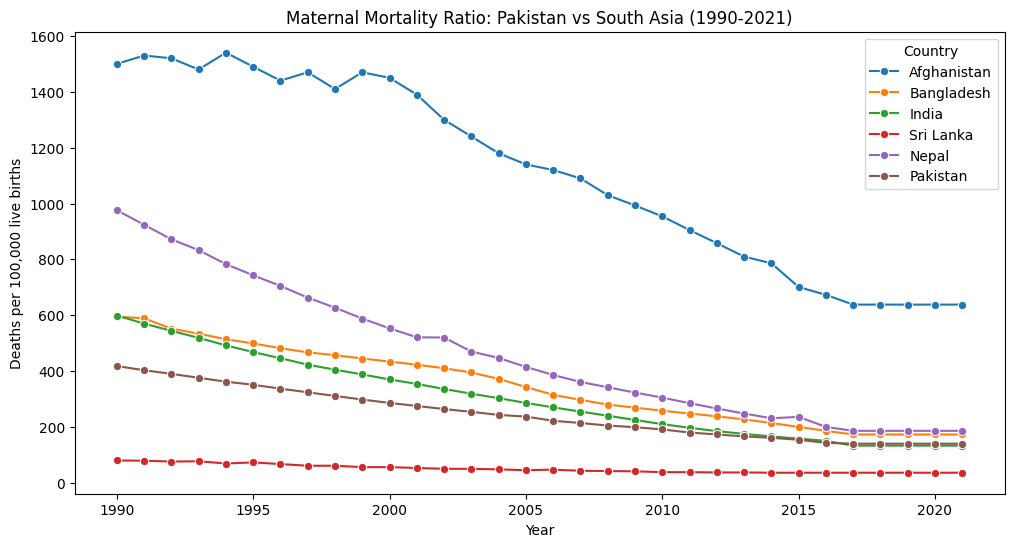

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_long , x='Year', y= 'Mortality' , hue='Country' , marker='o')
plt.title('Maternal Mortality Ratio: Pakistan vs South Asia (1990-2021)')
plt.ylabel('Deaths per 100,000 live births')
plt.show()

### Interpretation of the Chart

- **Sri Lanka** has had the lowest maternal mortality ratio throughout the entire 1990–2021 period — it started far ahead of its neighbors and stayed there.
- **Afghanistan** is in a separate league of its own, with mortality far above every other country in the region despite major improvement.
- **Pakistan and Bangladesh** tracked closely from 1990 to roughly 2010. After that, Bangladesh and India's lines drop below Pakistan's and stay there — Pakistan's line flattens out around 2015–2017 while its neighbors kept improving.
- By 2021, **Pakistan ranks second-highest in the group**, ahead of only Afghanistan — a notable shift from its relatively strong starting position in 1990.

## Step 6: Calculate % Improvement (1990 → 2021)

The chart shows *current rate*, but it doesn't show *how much each country improved relative to where it started*. A country with a low current rate (like Sri Lanka) isn't necessarily the most improved — it may have simply started in a strong position. To measure actual progress, we calculate percent decrease:

**% Improvement = (1990 value − 2021 value) / 1990 value × 100**

This tells us what fraction of the original 1990 mortality rate has been eliminated by 2021.

In [16]:
southasia = southasia.copy()
southasia['Pct_Improvement'] = (
    (southasia['Maternal Mortality Ratio (deaths per 100,000 live births) (1990)'] - 
     southasia['Maternal Mortality Ratio (deaths per 100,000 live births) (2021)']) / 
    southasia['Maternal Mortality Ratio (deaths per 100,000 live births) (1990)'] * 100
)
southasia[['Country', 'Pct_Improvement']].sort_values('Pct_Improvement', ascending=False)


,Country,Pct_Improvement
131,Nepal,80.942623
78,India,77.796327
15,Bangladesh,70.924370
135,Pakistan,66.507177
0,Afghanistan,57.466667
102,Sri Lanka,55.000000


## Summary of Findings

1. **Nepal had the most dramatic improvement (80.9%)** — despite starting from one of the worst positions in the region (976 in 1990), it nearly caught up to its neighbors by 2021.
2. **Pakistan improved by 66.5%, but ranks 4th out of 6** in relative improvement — behind Nepal, India, and Bangladesh.
3. **Sri Lanka shows the lowest % improvement (55%)**, but this is misleading on its own: it started so far ahead of the region (80 in 1990) that there was less room to improve. Lowest improvement ≠ worst performance — it's the opposite here.
4. **Pakistan's progress visibly stalled after 2017**, flatlining at 140 while India and Bangladesh continued to decline. This plateau is the most actionable finding — it raises the question of *why* progress halted, which would be a strong direction for further research (policy changes, healthcare access, regional disparities within Pakistan).

**Next steps:** Part 2 of this project will shift from country-level trends to individual-level clinical data (blood pressure, blood sugar, BMI, mental health) to explore what specific health factors are associated with high-risk pregnancies.